# Extracellular Electrode Locations vs. Circuit Somas

This notebook exercises the two patterned extracellular-electrode blocks and plots the resulting
electrode positions relative to the neuron somas of a small SONATA circuit:

- **`LinearExtracellularLocations`** — electrodes evenly spaced along a line.
- **`Neuropixels1ExtracellularLocations`** — a Neuropixels 1.0 staggered two-column layout.

Both derive from `PatternedExtracellularLocations`, which defines the pattern in a *local* frame
(origin at `(0, 0, 0)`, array running along the local `+Y` axis) and then rigidly places it into
world coordinates by rotating the local `+Y` axis onto the `direction` vector and translating by
`origin` (`get_global_electrode_xyz_locations`).

We also assert two properties that recent fixes guarantee:

1. the linear array's true inter-electrode distance equals its configured `spacing` — previously
   it ran along the `(1, 1, 1)` diagonal, so the spacing was inflated by √3;
2. every Neuropixels electrode has a distinct position — previously the second half of the sites
   overlapped the first half because the vertical index wrapped around with `%`.

In [1]:
from pathlib import Path

import bluepysnap as snap
import matplotlib.pyplot as plt
import numpy as np

import obi_one as obi

## Load the circuit and its soma positions

In [2]:
CIRCUIT_SUBPATH = Path("examples/data/tiny_circuits/N_10__top_nodes_dim6")


def resolve_repo_path(subpath: Path) -> Path:
    """Locate a repo-relative path by walking up from the current working directory."""
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidate = base / subpath
        if candidate.exists():
            return candidate
    raise FileNotFoundError(subpath)


circuit = snap.Circuit(str(resolve_repo_path(CIRCUIT_SUBPATH) / "circuit_config.json"))

# Somas of the (non-virtual) biophysical population.
biophysical_pops = [
    name for name in circuit.nodes.population_names if circuit.nodes[name].type != "virtual"
]
soma_population = biophysical_pops[0]
soma_xyz = circuit.nodes[soma_population].get(properties=["x", "y", "z"]).to_numpy()
soma_centroid = soma_xyz.mean(axis=0)

# Principal axis of the soma cloud (used to orient a probe through the neurons).
_, _, principal_axes = np.linalg.svd(soma_xyz - soma_centroid, full_matrices=False)
soma_principal_axis = principal_axes[0]

print(f"Population {soma_population!r}: {len(soma_xyz)} somas")
print(f"Centroid (um):   {np.round(soma_centroid, 1)}")
print(f"Principal axis:  {np.round(soma_principal_axis, 3)}")

Population 'S1nonbarrel_neurons': 10 somas
Centroid (um):   [ 3695.6 -1089.  -2797.8]
Principal axis:  [-0.657  0.244 -0.713]


## Helpers: place a probe near the somas and plot it

In [3]:
def build_probe_through_somas(array_cls, centroid, direction, **params):
    """Build an electrode array centred on ``centroid`` and oriented along ``direction``.

    Returns the configured block and its world-coordinate electrode positions, shape ``(N, 3)``.
    """
    unit_direction = np.asarray(direction, dtype=float)
    unit_direction = unit_direction / np.linalg.norm(unit_direction)

    # The local pattern is independent of origin/direction, so read it from a probe built with the
    # requested parameters, then offset the origin by half the array length to centre the array on
    # the centroid.
    local_xyz = np.asarray(array_cls(**params).get_local_electrode_xyz_locations(), dtype=float)
    array_length = local_xyz[:, 1].max() - local_xyz[:, 1].min()
    origin = np.asarray(centroid, dtype=float) - 0.5 * array_length * unit_direction

    probe = array_cls(
        origin_x=float(origin[0]),
        origin_y=float(origin[1]),
        origin_z=float(origin[2]),
        direction_x=float(unit_direction[0]),
        direction_y=float(unit_direction[1]),
        direction_z=float(unit_direction[2]),
        **params,
    )
    world_xyz = np.asarray(probe.get_global_electrode_xyz_locations(), dtype=float)
    return probe, world_xyz


def plot_projections(soma_xyz, electrode_xyz, title):
    """Plot XY / XZ / YZ projections of somas (grey) and electrodes (red)."""
    axis_labels = ["X", "Y", "Z"]
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, (i, j) in zip(axes, [(0, 1), (0, 2), (1, 2)], strict=True):
        ax.scatter(
            soma_xyz[:, i],
            soma_xyz[:, j],
            s=90,
            c="tab:gray",
            edgecolors="black",
            linewidths=0.5,
            alpha=0.8,
            label="somas",
        )
        ax.scatter(
            electrode_xyz[:, i], electrode_xyz[:, j], s=14, c="tab:red", label="electrodes"
        )
        ax.set_xlabel(f"{axis_labels[i]} (um)")
        ax.set_ylabel(f"{axis_labels[j]} (um)")
        ax.set_aspect("equal", adjustable="datalim")
        ax.grid(alpha=0.3)
    axes[0].legend(loc="best")
    fig.suptitle(title)
    fig.tight_layout()
    return fig

## `LinearExtracellularLocations`

16 electrodes spaced 50 um apart, oriented along the soma cloud's principal axis and centred on
its centroid. Because the array is defined in a local frame and rotated onto `direction`, the
measured inter-electrode distance matches `spacing` regardless of orientation.

Configured spacing:      50.0 um
Measured step distances: [50. 50. 50.] ... um


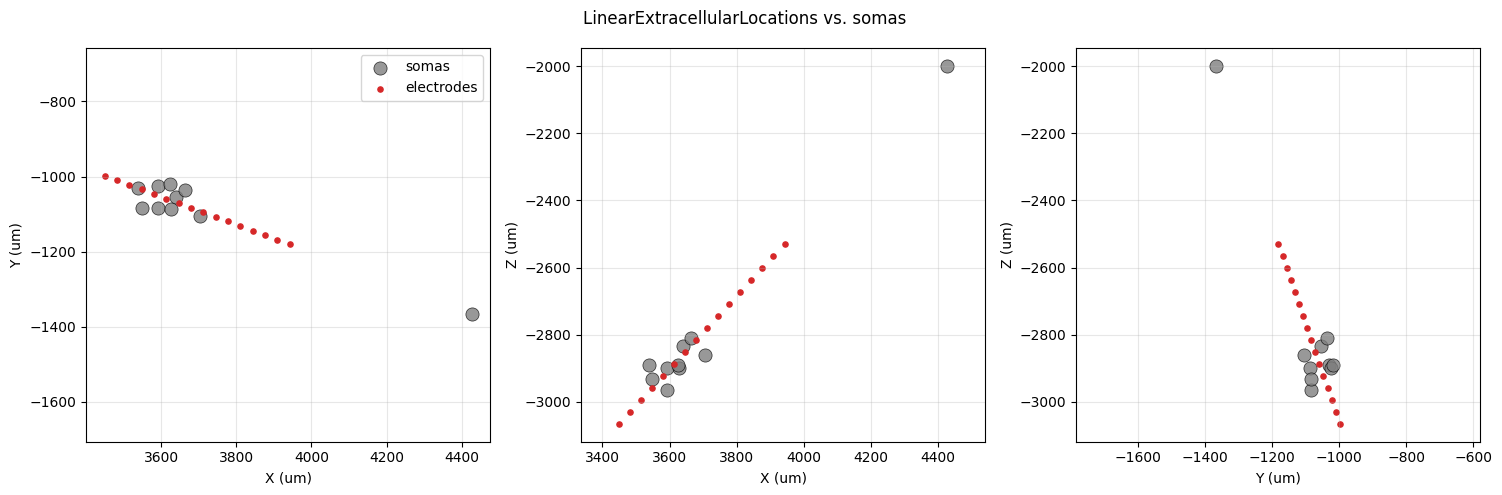

In [4]:
linear_spacing = 50.0
linear_probe, linear_xyz = build_probe_through_somas(
    obi.LinearExtracellularLocations,
    soma_centroid,
    soma_principal_axis,
    n_electrodes=16,
    spacing=linear_spacing,
)

# The true distance between consecutive electrodes must equal the configured spacing.
step_distances = np.linalg.norm(np.diff(linear_xyz, axis=0), axis=1)
print(f"Configured spacing:      {linear_spacing} um")
print(f"Measured step distances: {np.round(step_distances[:3], 3)} ... um")
assert np.allclose(step_distances, linear_spacing), "linear spacing should equal `spacing`"

plot_projections(soma_xyz, linear_xyz, "LinearExtracellularLocations vs. somas")
plt.show()

## `Neuropixels1ExtracellularLocations`

A Neuropixels 1.0 staggered two-column layout. We use 96 sites here so the probe is a comparable
scale to this tiny 10-neuron circuit (the default is 384 sites, i.e. a ~3.8 mm shank). This time
the array keeps its default vertical `direction` of `(0, 1, 0)` — so in the combined 3D view
below it crosses the tilted linear probe at the centroid. Every electrode must map to a distinct
position.

Electrodes:        96
Unique positions:  96


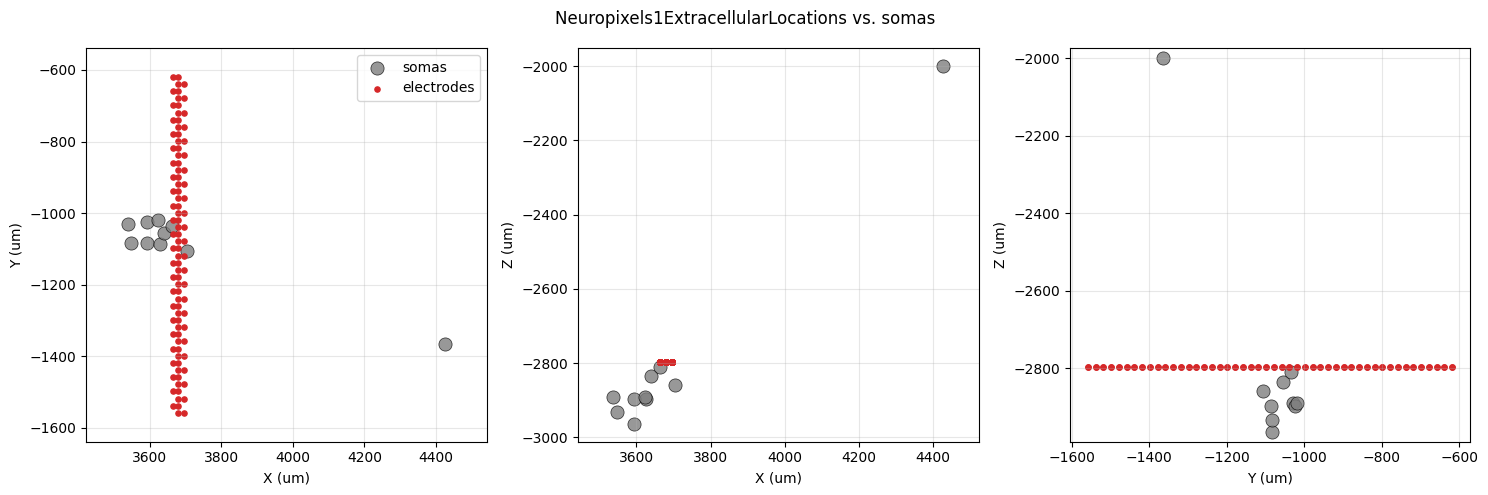

In [15]:
neuropixels_probe, neuropixels_xyz = build_probe_through_somas(
    obi.Neuropixels1ExtracellularLocations,
    soma_centroid,
    (0.0, 1.0, 0.0),
    n_electrodes=96,
    axial_rotation=180,
)

n_unique = len({tuple(np.round(position, 6)) for position in neuropixels_xyz})
print(f"Electrodes:        {len(neuropixels_xyz)}")
print(f"Unique positions:  {n_unique}")
assert n_unique == len(neuropixels_xyz), "every Neuropixels electrode must be at a distinct position"

plot_projections(soma_xyz, neuropixels_xyz, "Neuropixels1ExtracellularLocations vs. somas")
plt.show()

### Neuropixels layout in the probe's local frame

Viewing the raw pattern (`get_local_electrode_xyz_locations`, before origin/direction are applied) shows the
staggered two-column checkerboard and confirms the sites do not overlap.

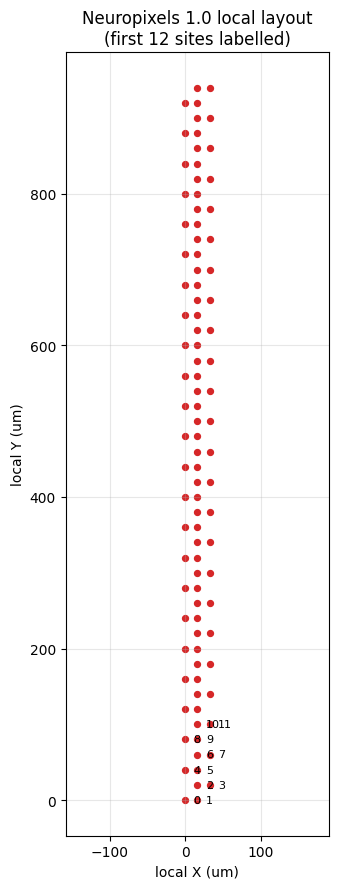

In [13]:
local_xyz = np.asarray(neuropixels_probe.get_local_electrode_xyz_locations(), dtype=float)

fig, ax = plt.subplots(figsize=(3.5, 9))
ax.scatter(local_xyz[:, 0], local_xyz[:, 1], s=18, c="tab:red")
for idx, (x, y, _) in enumerate(local_xyz[:12]):
    ax.annotate(str(idx), (x, y), textcoords="offset points", xytext=(6, -2), fontsize=8)
ax.set_xlabel("local X (um)")
ax.set_ylabel("local Y (um)")
ax.set_title("Neuropixels 1.0 local layout\n(first 12 sites labelled)")
ax.set_aspect("equal", adjustable="datalim")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

### Effect of `axial_rotation`

`axial_rotation` rolls the probe about its long axis (local `+Y`). Viewed end-on — the local X-Z
cross-section, i.e. looking straight down the probe — the staggered electrode face rotates in
place: at 0° the columns lie flat in the local X-Y plane (all Z = 0), and at 90° they stand up
along local Z. It defaults to 0 and is a no-op for the 1-D linear probe.

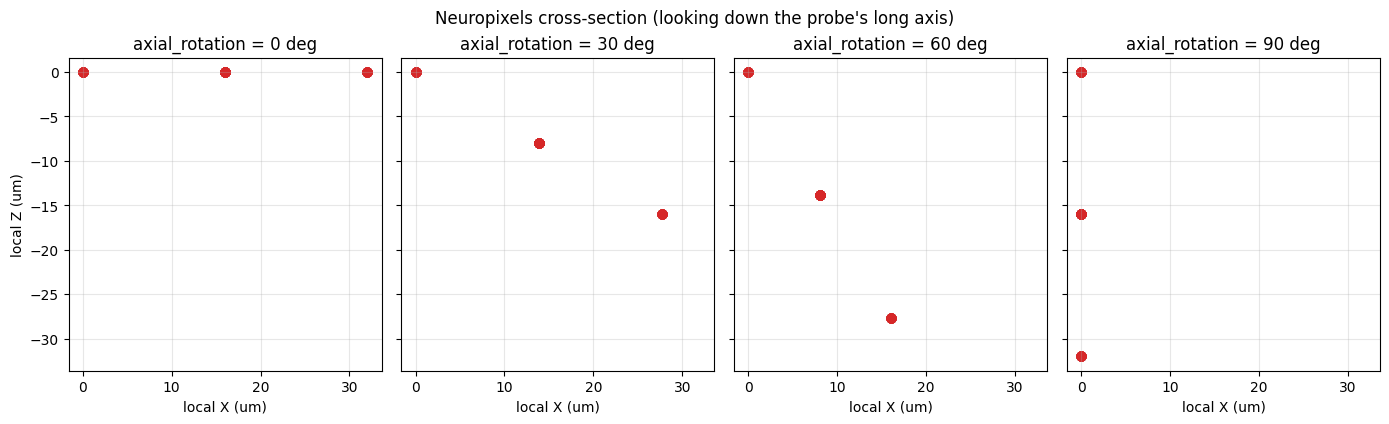

In [7]:
roll_angles = [0.0, 30.0, 60.0, 90.0]
fig, axes = plt.subplots(1, len(roll_angles), figsize=(14, 4), sharex=True, sharey=True)
for ax, angle in zip(axes, roll_angles, strict=True):
    rolled_xyz = np.asarray(
        obi.Neuropixels1ExtracellularLocations(
            n_electrodes=96, axial_rotation=angle
        ).get_local_electrode_xyz_locations(),
        dtype=float,
    )
    ax.scatter(rolled_xyz[:, 0], rolled_xyz[:, 2], s=40, c="tab:red", alpha=0.6)
    ax.set_title(f"axial_rotation = {angle:g} deg")
    ax.set_xlabel("local X (um)")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("local Z (um)")
fig.suptitle("Neuropixels cross-section (looking down the probe's long axis)")
fig.tight_layout()
plt.show()

## Combined 3D view

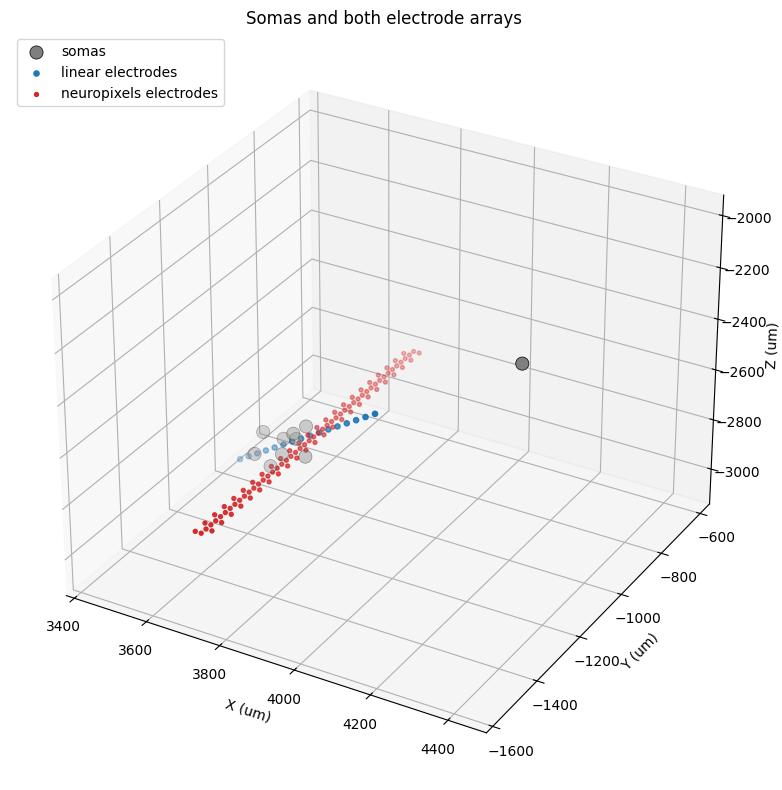

In [8]:
fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(projection="3d")
ax.scatter(*soma_xyz.T, s=90, c="tab:gray", edgecolors="black", linewidths=0.5, label="somas")
ax.scatter(*linear_xyz.T, s=14, c="tab:blue", label="linear electrodes")
ax.scatter(*neuropixels_xyz.T, s=8, c="tab:red", label="neuropixels electrodes")
ax.set_xlabel("X (um)")
ax.set_ylabel("Y (um)")
ax.set_zlabel("Z (um)")
ax.set_title("Somas and both electrode arrays")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()